In [107]:
#Import bibliotek i wczytywanie danych
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_airbnb = pd.read_csv("/content/sample_data/Airbnb_Open_Data.csv")
df_airbnb.head()

/tmp/ipykernel_190/1743511578.py:6: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df_airbnb = pd.read_csv("/content/sample_data/Airbnb_Open_Data.csv")


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,$193,10.0,9.0,10/19/2021,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,$28,30.0,45.0,5/21/2022,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,$124,3.0,0.0,NaN,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,$74,30.0,270.0,7/5/2019,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,$41,10.0,9.0,11/19/2018,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


In [108]:
#Sprawdzenie danych
df_airbnb.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102599 non-null  int64  
 1   NAME                            102349 non-null  object 
 2   host id                         102599 non-null  int64  
 3   host_identity_verified          102310 non-null  object 
 4   host name                       102193 non-null  object 
 5   neighbourhood group             102570 non-null  object 
 6   neighbourhood                   102583 non-null  object 
 7   lat                             102591 non-null  float64
 8   long                            102591 non-null  float64
 9   country                         102067 non-null  object 
 10  country code                    102468 non-null  object 
 11  instant_bookable                102494 non-null  object 
 12  cancellation_pol

In [109]:
df_airbnb.isnull().sum().sort_values(ascending=False)

,0
license,102597
house_rules,52131
last review,15893
reviews per month,15879
country,532
availability 365,448
minimum nights,409
host name,406
review rate number,326
calculated host listings count,319


In [110]:
df_airbnb.describe()

,id,host id,lat,long,Construction year,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365
count,1.025990e+05,1.025990e+05,102591.000000,102591.000000,102385.000000,102190.000000,102416.000000,86720.000000,102273.000000,102280.000000,102151.000000
mean,2.914623e+07,4.925411e+10,40.728094,-73.949644,2012.487464,8.135845,27.483743,1.374022,3.279106,7.936605,141.133254
std,1.625751e+07,2.853900e+10,0.055857,0.049521,5.765556,30.553781,49.508954,1.746621,1.284657,32.218780,135.435024
min,1.001254e+06,1.236005e+08,40.499790,-74.249840,2003.000000,-1223.000000,0.000000,0.010000,1.000000,1.000000,-10.000000
25%,1.508581e+07,2.458333e+10,40.688740,-73.982580,2007.000000,2.000000,1.000000,0.220000,2.000000,1.000000,3.000000
50%,2.913660e+07,4.911774e+10,40.722290,-73.954440,2012.000000,3.000000,7.000000,0.740000,3.000000,1.000000,96.000000
75%,4.320120e+07,7.399650e+10,40.762760,-73.932350,2017.000000,5.000000,30.000000,2.000000,4.000000,2.000000,269.000000
max,5.736742e+07,9.876313e+10,40.916970,-73.705220,2022.000000,5645.000000,1024.000000,90.000000,5.000000,332.000000,3677.000000


In [111]:
#Czyszczenie Danych
#kolumna "license" ma tylko 2 wartości - praktycznie bezużyteczna - usuwam
df_airbnb = df_airbnb.drop(columns=['license'])
#kolumna "house_rules" nie ma dla naszej analizy żadnej wartości - usuwam
df_airbnb = df_airbnb.drop(columns=['house_rules'])
#kolumna "last review" do projektu cenowego niepotrzebne - usuwam
df_airbnb = df_airbnb.drop(columns=['last review'])
#kolumna "reviews per month" null zamieniamy na 0
df_airbnb['reviews per month'] = df_airbnb['reviews per month'].fillna(0)
#wiersze z brakującymi danymi w kolumnie "price" - 247 braków - nie wymyślam konkretnych cen - usuwam wiersze
df_airbnb = df_airbnb.dropna(subset=['price'])
#to samo dla "neighbourhood group"
df_airbnb = df_airbnb.dropna(subset=["neighbourhood group"])

In [112]:
#dane w kolumnie "price" przekształcamy w liczby float
df_airbnb['price'] = (
    df_airbnb['price']
    .str.replace('$','',regex=False)
    .str.replace(',','',regex=False)
    .astype(float)
)

In [113]:
#sprawdzam kolumne "price"
df_airbnb['price']

,price
0,966.0
1,142.0
2,620.0
3,368.0
4,204.0
...,...
102594,844.0
102595,837.0
102596,988.0
102597,546.0


In [114]:
#dla kolumny "service fee" - konwertuje wartosci do liczby float
df_airbnb['service fee'] = (
    df_airbnb['service fee']
    .str.replace('$','',regex=False) #usuwa znak $
    .str.replace(',','',regex=False) #usuwa znak ,
    .astype(float) #zmienia typ na float
)

In [115]:
#braki uzupełniam medianą
df_airbnb['service fee'] = df_airbnb['service fee'].fillna(df_airbnb['service fee'].median())

In [116]:
#kolumna " host_identify_verified" - braki uzupełniamy "unknown"
df_airbnb['host_identity_verified'] = df_airbnb['host_identity_verified'].fillna('unknown')

In [117]:
#kolumna "host name" - w tym projekcie nieistotna - usuwam
df_airbnb = df_airbnb.drop(columns=['host name'])

In [118]:
#kolumna "minimum nights" - braki uzupełniamy medianą
df_airbnb['minimum nights'] = df_airbnb['minimum nights'].fillna(df_airbnb['minimum nights'].median())

In [119]:
#kolumny poniżej - braki uzupełniamy medianą
df_airbnb['availability 365'] = df_airbnb['availability 365'].fillna(df_airbnb['availability 365'].median())
df_airbnb['Construction year'] = df_airbnb['Construction year'].fillna(df_airbnb['Construction year'].median())
df_airbnb['review rate number'] = df_airbnb['review rate number'].fillna(df_airbnb['review rate number'].median())
df_airbnb['calculated host listings count'] = df_airbnb['calculated host listings count'].fillna(df_airbnb['calculated host listings count'].median())

In [120]:
#braki uzupełniamy "unknown"
df_airbnb['country'] = df_airbnb['country'].fillna('unknown')
df_airbnb['country code'] = df_airbnb['country code'].fillna('unknown')

Podsumowanie czyszczenia danych:
*   usunięto kolumny z >50% braków
*   imputowano zmienne numeryczne medianą (odporność na outliery)
*   imputowano zmienne kategoryczne jako unknown
*   usunięto rekordy z brakującą ceną (zmienna target)
*   Kolumny price oraz service fee zawierały symbole walutowe i separatory tysięcy. Zostały one usunięte przy użyciu metod stringowych, a następnie przekonwertowane do typu float, aby umożliwić analizę ilościową.


In [121]:
df_airbnb["price"].describe()

,price
count,102324.000000
mean,625.284488
std,331.671523
min,50.000000
25%,340.000000
50%,624.000000
75%,913.000000
max,1200.000000


Opis "price":
*   min = 50 brak podejrzanych zer
*   max = 1200 brak ekstremalnych outlierów
*   mean ≈ median rozkład prawie symetryczny
*   std = 331 duża zmienność cen
*   Q1 = 340 / Q3 = 913 szeroki zakres cen
*   kluczowy insight: rynek Airbnb jest mocno zróżnicowany cenowo

Outliery metodą IQR:
*   IQR = Q3 − Q1 = 913 − 340 = 573
*   Upper bound = 913 + 1.5*573 = 1772
*   max = 1200 < 1772
*   brak outlierów


In [122]:
#Tworzę kategorię cen
def price_category(price):
    if price < 200:
        return "low"
    elif price <= 500:
        return "medium"
    else:
        return "high"

df_airbnb["price_category"] = df_airbnb["price"].apply(price_category)

In [123]:
df_airbnb["price_category"].value_counts()

,count
price_category,
high,62318
medium,26836
low,13170


Na podstawie rozkładu cen stworzyłam zmienną price_category dzielącą oferty na segment low, medium oraz high, co umożliwia analizę strategii cenowej i identyfikację docelowych segmentów rynku.

*   high	62k	dominują droższe oferty
*   medium	26k	mniejszy segment
*   low	13k	nisza cenowa
*   rynek jest przesunięty w stronę wysokich cen
*   duża konkurencja w segmencie high
*   segment low ma małą podaż → potencjalna nisza
*   segment medium = kompromis strategii


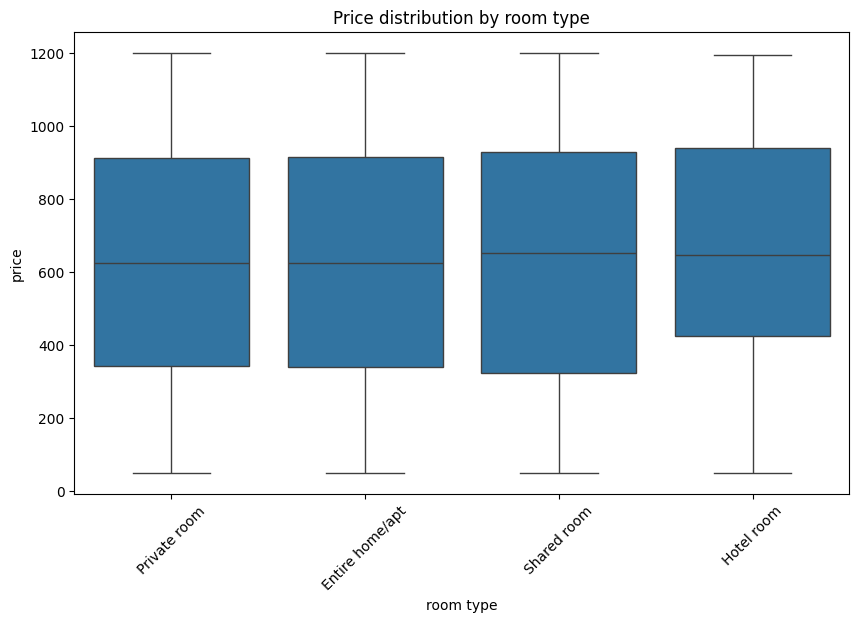

In [124]:
#wykres price vs room type - chcę się dowiedzieć jaki typ nieruchomości najbardziej wpływa na cenę
plt.figure(figsize=(10,6))
sns.boxplot(x="room type", y="price", data=df_airbnb)
plt.title("Price distribution by room type")
plt.xticks(rotation=45)
plt.show()

Analiza rozkładu cen według typu pokoju wykazała, że mediany cen są zbliżone między kategoriami. Sugeruje to, że typ nieruchomości nie jest głównym czynnikiem determinującym cenę. Jednocześnie duża zmienność cen w każdej kategorii wskazuje na istotny wpływ innych zmiennych, takich jak lokalizacja, dostępność czy opinie użytkowników.

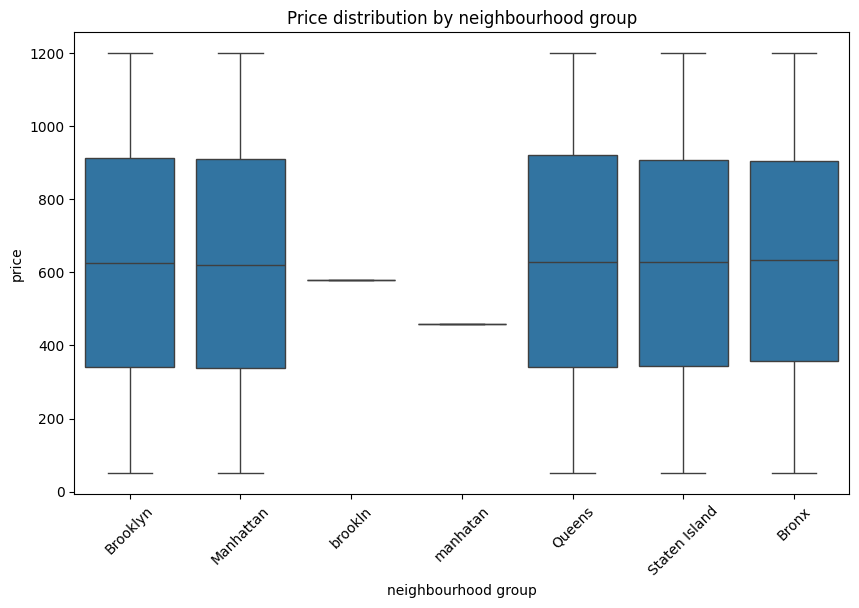

In [125]:
#wykres price vs neighbourhood group - jak dzielnica wpływa na cenę
plt.figure(figsize=(10,6))
sns.boxplot(x="neighbourhood group", y="price", data=df_airbnb)
plt.title("Price distribution by neighbourhood group")
plt.xticks(rotation=45)
plt.show()

In [126]:
#usuwanie literówek w nazwach dzielnic
df_airbnb['neighbourhood group'] = (
    df_airbnb['neighbourhood group']
    .str.lower()
    .replace({
        'brookln' : 'Brooklyn',
        'manhatan' : 'Manhattan'
    })
    .str.title()
)

In [127]:
df_airbnb['neighbourhood group'].value_counts()

,count
neighbourhood group,
Manhattan,43683
Brooklyn,41750
Queens,13234
Bronx,2705
Staten Island,952


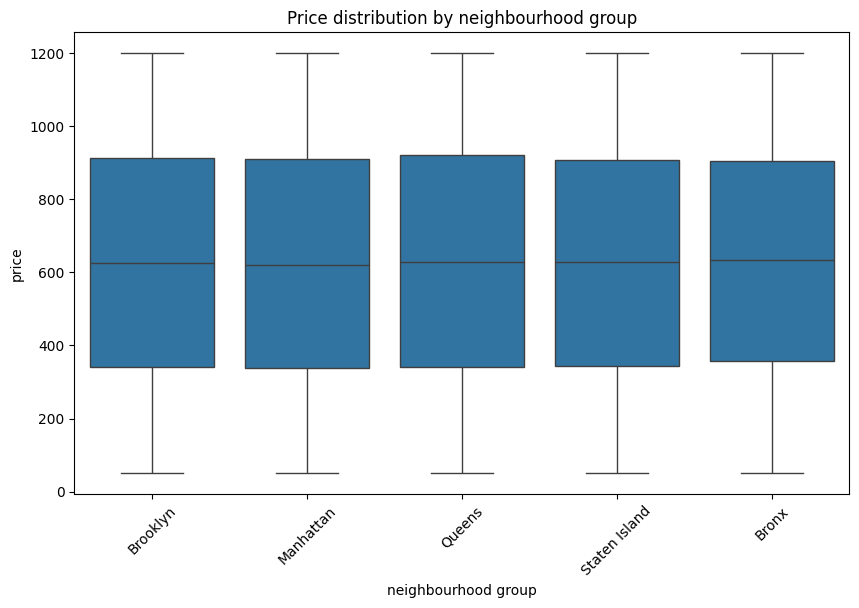

In [128]:
#poprawiony wykres
plt.figure(figsize=(10,6))
sns.boxplot(x="neighbourhood group", y="price", data=df_airbnb)
plt.title("Price distribution by neighbourhood group")
plt.xticks(rotation=45)
plt.show()

Analiza cen według dzielnic wykazała niewielkie różnice między medianami cen. Duża zmienność w obrębie każdej dzielnicy wskazuje, że lokalizacja na poziomie dzielnicy nie jest wystarczającym predyktorem ceny i konieczna jest analiza dodatkowych czynników.

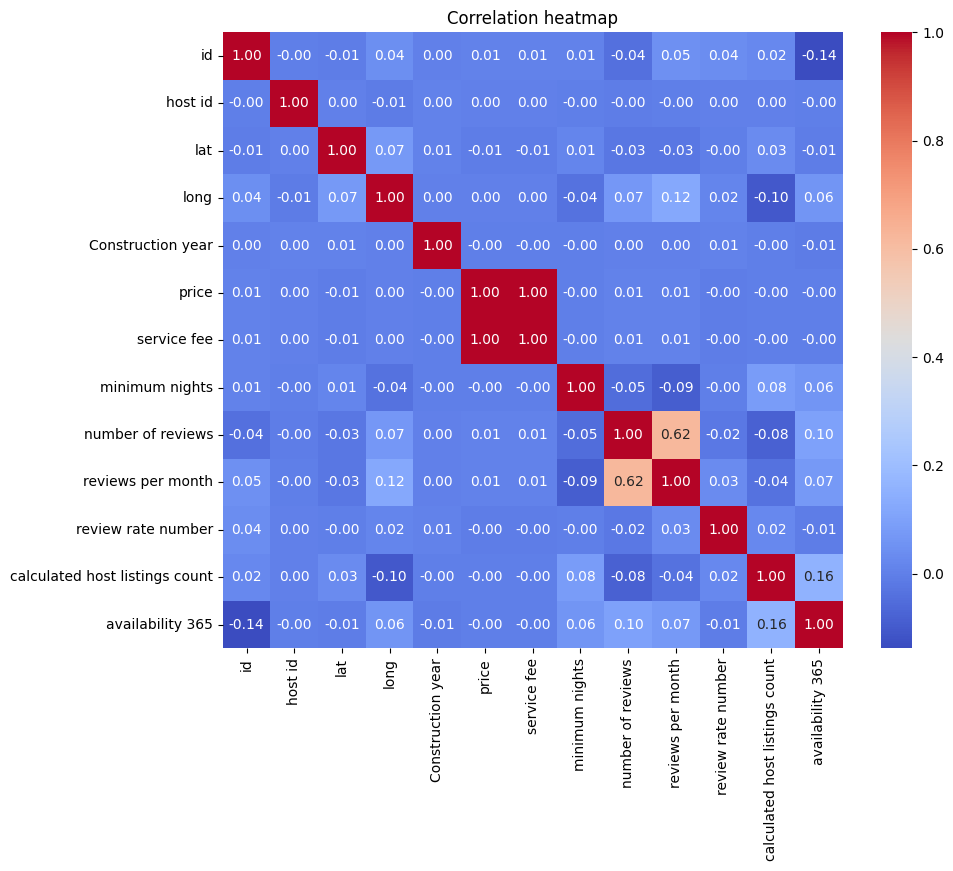

In [129]:
#heatmapa korelacji
plt.figure(figsize=(10,8))

numeric_cols = df_airbnb.select_dtypes(include="number")

sns.heatmap(numeric_cols.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation heatmap")
plt.show()

Analiza korelacji wykazała brak silnych zależności pomiędzy ceną a zmiennymi numerycznymi. Oznacza to, że cena ofert Airbnb jest prawdopodobnie determinowana przez kombinację różnych czynników, w szczególności zmiennych kategorycznych takich jak typ nieruchomości czy lokalizacja. Najsilniejsza korelacja została zaobserwowana między liczbą opinii a liczbą opinii miesięcznie (0.62), co jest zależnością naturalną.

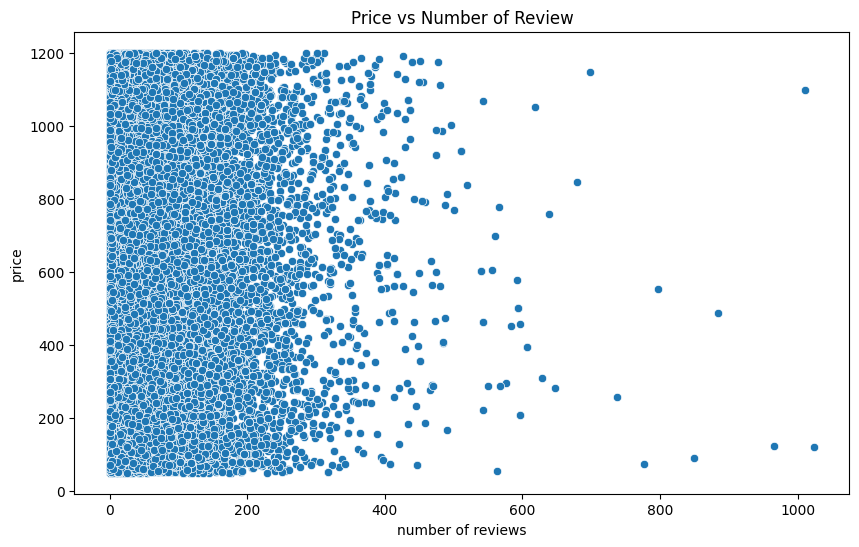

In [130]:
#Price vs Number of Reviews
plt.figure(figsize=(10,6))
sns.scatterplot(x='number of reviews',y='price', data=df_airbnb)
plt.title('Price vs Number of Review')
plt.show()

Analiza zależności między ceną a liczbą opinii nie wykazała silnej korelacji. Oferty o różnych poziomach cen występują przy każdej liczbie opinii. Widać jednak, że większość ofert posiada relatywnie niewielką liczbę recenzji, co może wskazywać na dużą rotację ofert lub stosunkowo krótką historię wielu ogłoszeń.

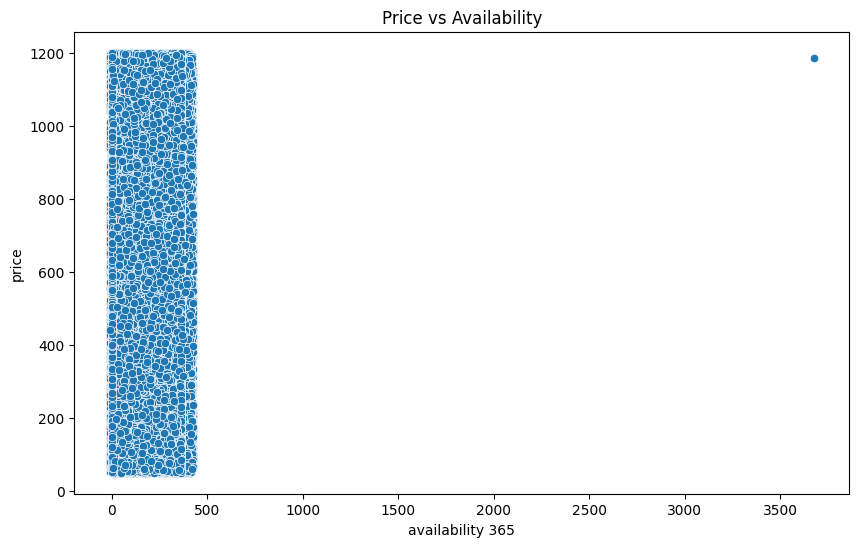

In [131]:
#Price vs Availability
plt.figure(figsize=(10,6))
sns.scatterplot(x='availability 365',y='price',data=df_airbnb)
plt.title('Price vs Availability')
plt.show()

In [132]:
#Na osi availability 365 pojawia się punkt około 3600 - kolumna oznacza liczbe dni dostepnosci w roku - wartość powyzej 365 jest niemożliwa
df_airbnb['availability 365'].describe()

,availability 365
count,102324.000000
mean,140.918778
std,135.169393
min,-10.000000
25%,3.000000
50%,96.000000
75%,268.000000
max,3677.000000


In [133]:
#jest 2771 wierszy z błędną wartością
df_airbnb[df_airbnb['availability 365'] > 365]

,id,NAME,host id,host_identity_verified,neighbourhood group,neighbourhood,lat,long,country,country code,...,Construction year,price,service fee,minimum nights,number of reviews,reviews per month,review rate number,calculated host listings count,availability 365,price_category
5,1004098,Large Cozy 1 BR Apartment In Midtown East,45498551794,verified,Manhattan,Murray Hill,40.74767,-73.97500,United States,US,...,2013.0,577.0,115.0,3.0,74.0,0.59,3.0,1.0,374.0,high
9,1006307,Cozy Clean Guest Room - Family Apt,75527839483,unconfirmed,Manhattan,Upper West Side,40.80178,-73.96723,United States,US,...,2015.0,291.0,58.0,2.0,118.0,0.99,5.0,1.0,375.0,medium
25,1015144,"MAISON DES SIRENES1,bohemian apartment",48387947293,unknown,Brooklyn,Bedford-Stuyvesant,40.68371,-73.94028,United States,unknown,...,2006.0,1175.0,235.0,2.0,88.0,0.73,4.0,2.0,372.0,high
33,1019562,Loft in Williamsburg Area w/ Roof,50968902783,unconfirmed,Brooklyn,Greenpoint,40.72219,-73.93762,United States,unknown,...,2007.0,858.0,172.0,4.0,197.0,1.65,3.0,3.0,383.0,high
34,1020114,back room/bunk beds,25066620900,verified,Manhattan,Harlem,40.82130,-73.95318,United States,unknown,...,2021.0,545.0,109.0,3.0,273.0,2.37,3.0,3.0,411.0,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
102582,6085810,Private room in the best part of BK,4746552394,verified,Brooklyn,Crown Heights,40.66743,-73.94712,United States,US,...,2011.0,516.0,103.0,7.0,49.0,1.01,2.0,1.0,425.0,high
102584,6086914,2 block walk from the beach in NYC,70051719594,verified,Queens,Arverne,40.59270,-73.78990,United States,US,...,2010.0,566.0,113.0,2.0,89.0,1.82,2.0,1.0,394.0,high
102588,6089124,"Loft Space for Events, Meetings & Shoots",85557432222,unconfirmed,Manhattan,Flatiron District,40.74068,-73.98999,United States,US,...,2016.0,618.0,124.0,1.0,177.0,3.78,4.0,1.0,410.0,high
102595,6092990,Best Location near Columbia U,77864383453,unconfirmed,Manhattan,Morningside Heights,40.80460,-73.96545,United States,US,...,2016.0,837.0,167.0,1.0,1.0,0.02,2.0,2.0,395.0,high


In [134]:
#usuwamy błędne rekordy
df_airbnb = df_airbnb[df_airbnb['availability 365'] <=365]

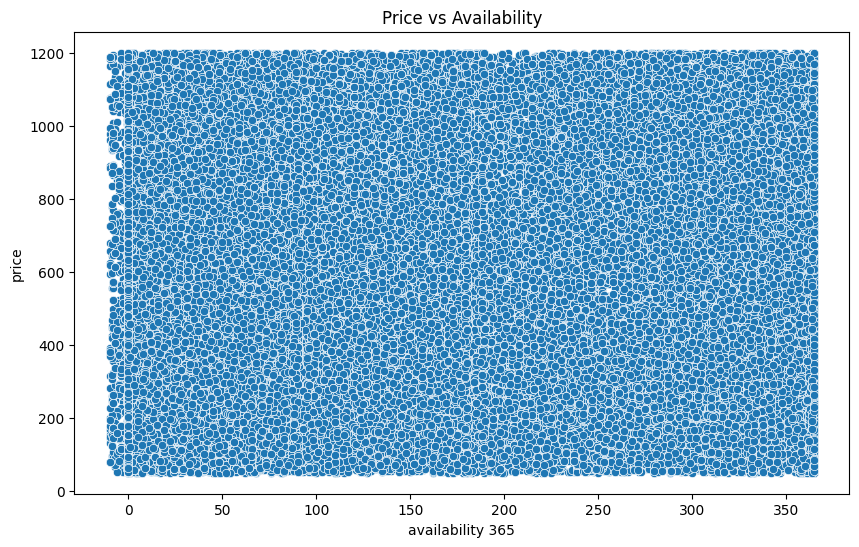

In [135]:
#powtażam wykres
plt.figure(figsize=(10,6))
sns.scatterplot(x='availability 365',y='price',data=df_airbnb)
plt.title('Price vs Availability')
plt.show()

Analiza zależności pomiędzy ceną a dostępnością oferty w ciągu roku nie wykazała wyraźnej korelacji. Oferty o różnych poziomach cen występują przy każdej wartości dostępności, co sugeruje, że strategia cenowa gospodarzy nie jest bezpośrednio związana z liczbą dni dostępności w roku.

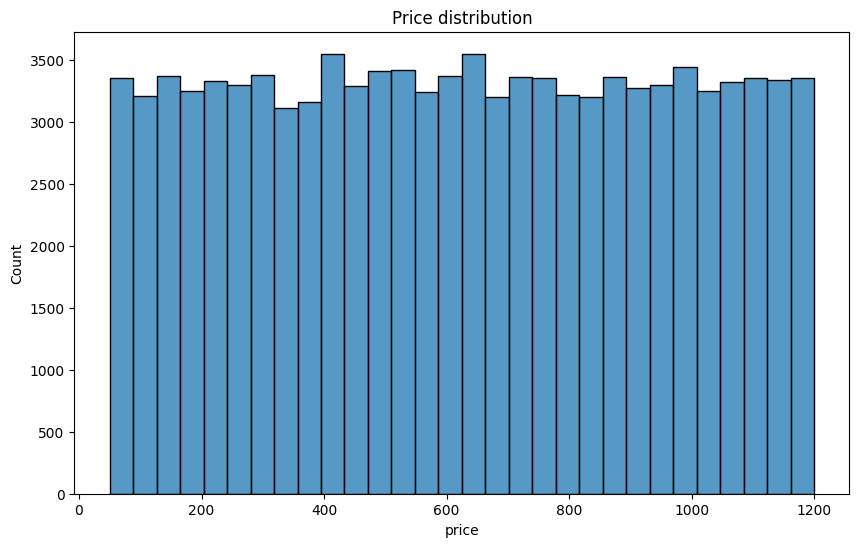

In [136]:
#histogram ceny (rozkład)
plt.figure(figsize=(10,6))
sns.histplot(df_airbnb["price"], bins=30)
plt.title("Price distribution")
plt.show()

Histogram cen wskazuje na stosunkowo równomierny rozkład wartości w analizowanym zbiorze danych. Oznacza to, że liczba ofert jest podobna w różnych przedziałach cenowych, co wskazuje na dużą różnorodność ofert dostępnych na platformie.

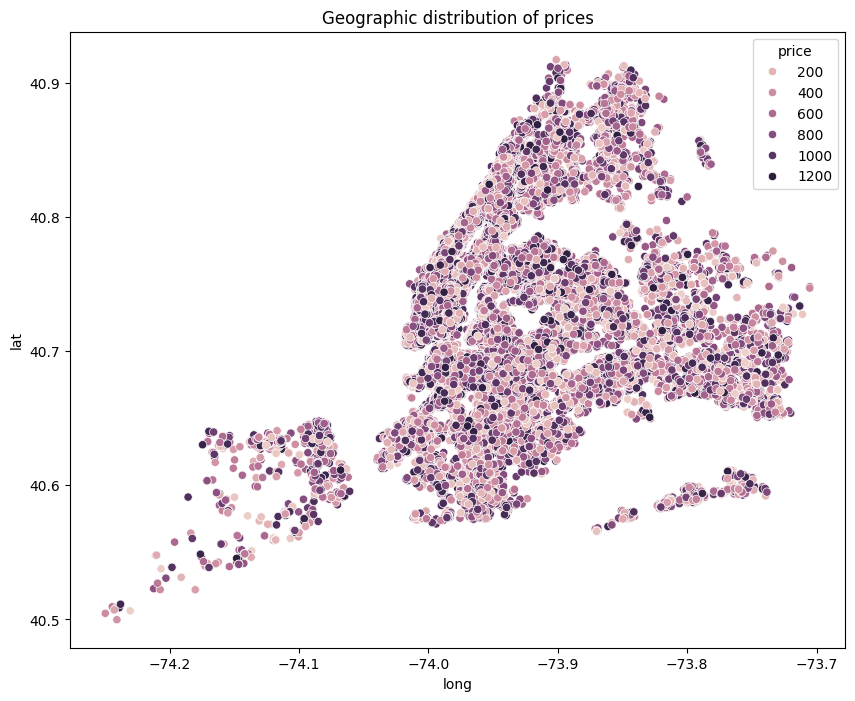

In [137]:
#rozmieszczenie geograficzne ofert
plt.figure(figsize=(10,8))
sns.scatterplot(x="long", y="lat", hue="price", data=df_airbnb)
plt.title("Geographic distribution of prices")
plt.show()

Wykres rozmieszczenia geograficznego pokazuje, że oferty Airbnb są skoncentrowane w centralnych obszarach miasta. Jednocześnie ceny ofert są rozproszone w różnych lokalizacjach, co sugeruje brak silnej zależności między położeniem geograficznym a ceną w analizowanym zbiorze danych.

Ogólne wnioski:

*   Rozkład cen jest stosunkowo równomierny w analizowanym zbiorze danych.
*   Lokalizacja geograficzna nie pokazuje wyraźnej koncentracji najdroższych ofert.

*   Liczba opinii nie wykazuje silnej zależności z ceną.
*   Typ pokoju wpływa na cenę w ograniczonym stopniu – zakresy cen są podobne.

*   Oferty Airbnb są skoncentrowane w centralnych obszarach miasta.


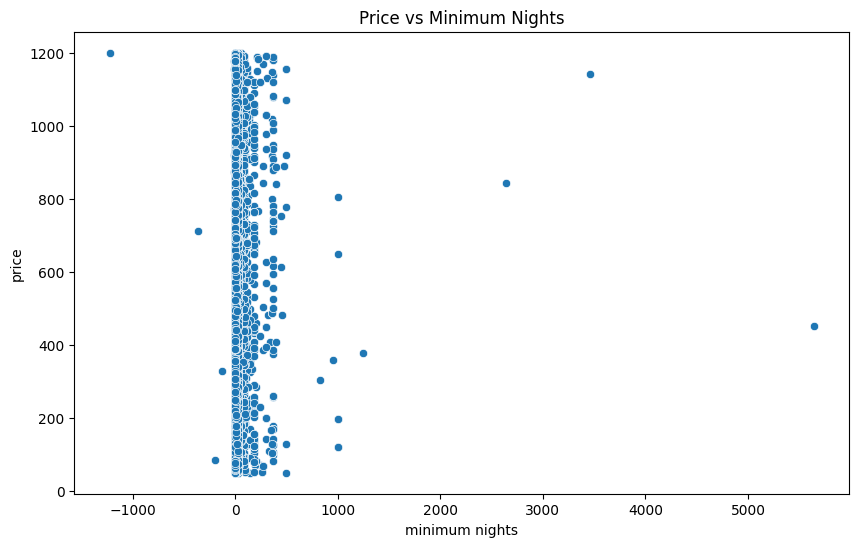

In [138]:
#Ten wykres pokazuje czy dłuższy minimalny pobyt wpływa na cenę
plt.figure(figsize=(10,6))
sns.scatterplot(x="minimum nights", y="price", data=df_airbnb)
plt.title("Price vs Minimum Nights")
plt.show()

Analiza zależności między minimalną liczbą nocy a ceną nie wskazuje na wyraźną korelację. Większość ofert posiada minimalny pobyt poniżej 50 nocy, a ceny pozostają zróżnicowane niezależnie od tego parametru.

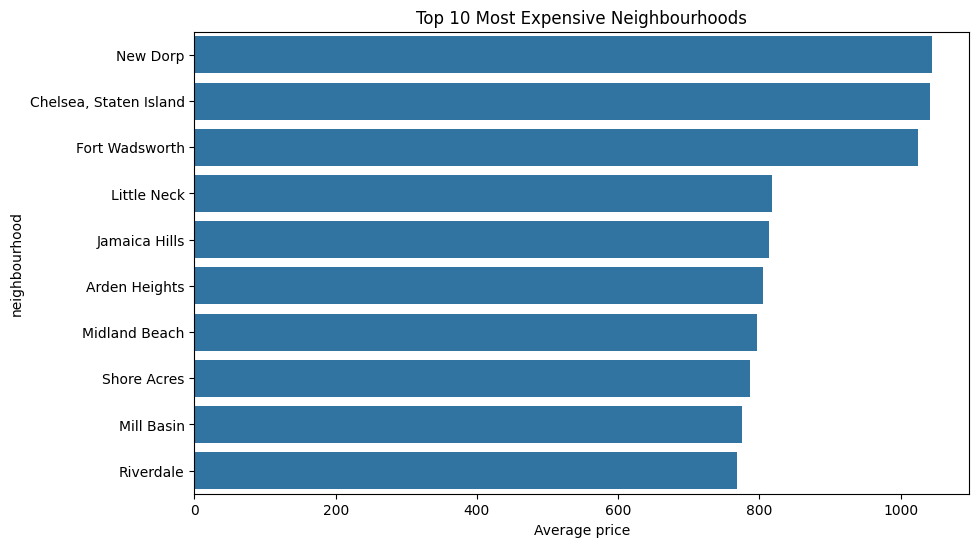

In [139]:
#konkretne dzielnice mające najwyższe średnie ceny (Średnia może być zawyżona, jeśli w dzielnicy jest mało ofert - do sprawdzenia)
top_neigh = (
    df_airbnb.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
sns.barplot(x=top_neigh.values, y=top_neigh.index)
plt.title("Top 10 Most Expensive Neighbourhoods")
plt.xlabel("Average price")
plt.show()

In [140]:
#ilość ofert pod kątem dzielnic
df_airbnb['neighbourhood'].value_counts()

,count
neighbourhood,
Bedford-Stuyvesant,7714
Williamsburg,7524
Harlem,5249
Bushwick,4832
Hell's Kitchen,3867
...,...
Rossville,3
Gerritsen Beach,3
Fort Wadsworth,2


In [141]:
#filtrujemy dzielnice z małą liczbą ofert - minimum 50
neigh_counts = df_airbnb['neighbourhood'].value_counts()

valid_neigh = neigh_counts[neigh_counts > 50].index

filtered = df_airbnb[df_airbnb['neighbourhood'].isin(valid_neigh)]

top_neigh = (
    filtered.groupby("neighbourhood")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

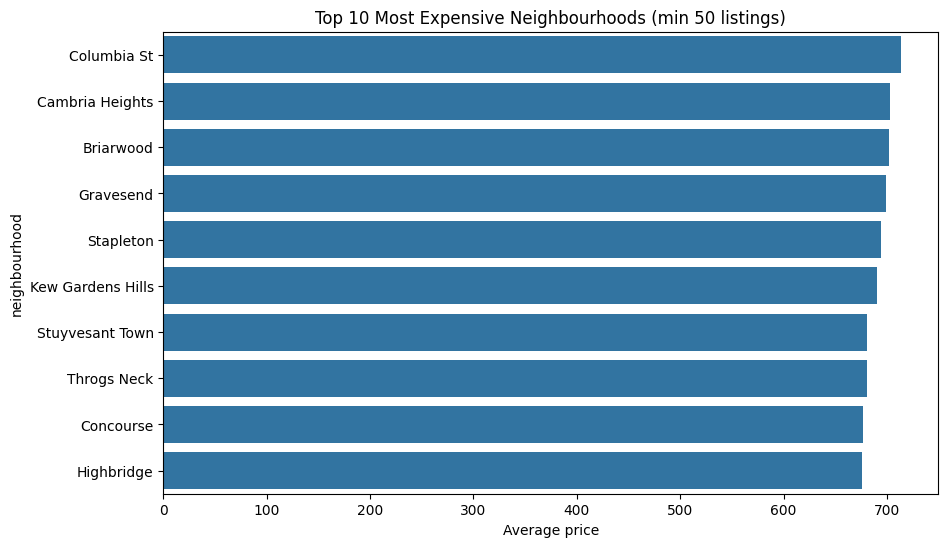

In [142]:
#powtarzamy wykres
plt.figure(figsize=(10,6))
sns.barplot(x=top_neigh.values, y=top_neigh.index)

plt.title("Top 10 Most Expensive Neighbourhoods (min 50 listings)")
plt.xlabel("Average price")
plt.show()

Po uwzględnieniu wyłącznie dzielnic z co najmniej 50 ofertami, analiza średnich cen pokazuje bardziej realistyczny obraz rynku. Najwyższe ceny występują w dzielnicach takich jak Theater District, Carroll Gardens czy East Elmhurst, jednak różnice między nimi są stosunkowo niewielkie.

Sugeruje to, że choć lokalizacja ma wpływ na poziom cen, to nie jest to czynnik dominujący – ceny w popularnych dzielnicach pozostają na zbliżonym poziomie.

Wskazuje to również na dużą konkurencję cenową w obrębie różnych lokalizacji, co oznacza, że gospodarze powinni uwzględniać nie tylko lokalizację, ale także inne aspekty oferty przy ustalaniu ceny.

In [143]:
#analiza segmentów cenowych
segment_analysis = df_airbnb.groupby("price_category").agg({
    "price": "mean",
    "number of reviews": "mean",
    "availability 365": "mean",
    "minimum nights": "mean"
})

segment_analysis

,price,number of reviews,availability 365,minimum nights
price_category,,,,
high,849.775140,27.426210,133.343093,7.987158
low,124.209033,26.289373,134.180042,8.784012
medium,350.432234,27.354867,134.674943,8.150362


Segmenty cenowe różnią się głównie poziomem ceny, natomiast inne analizowane cechy, takie jak liczba opinii, dostępność czy minimalna liczba nocy, pozostają na zbliżonym poziomie. Oznacza to, że różnice cenowe nie wynikają bezpośrednio z tych czynników, lecz prawdopodobnie z innych elementów, takich jak standard mieszkania, lokalizacja szczegółowa czy jakość oferty.

Brak istotnych różnic w liczbie opinii i dostępności między segmentami cenowymi sugeruje, że droższe oferty nie są bardziej popularne niż tańsze. W związku z tym gospodarze nie powinni zakładać, że wyższa cena automatycznie przełoży się na większe zainteresowanie ofertą.

Najbardziej efektywną strategią dla nowych gospodarzy może być wejście w segment średni cenowy, który łączy relatywnie wysoką liczbę opinii z umiarkowanym poziomem cen, minimalizując ryzyko braku rezerwacji.

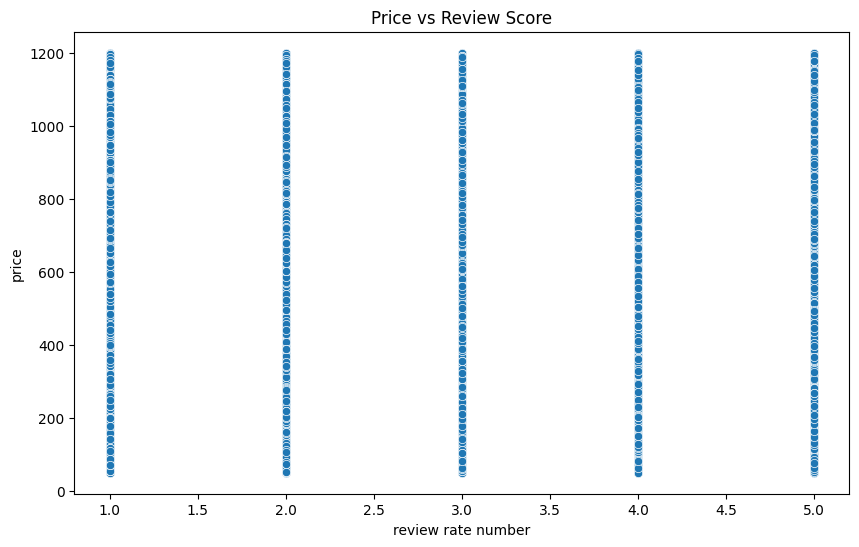

In [144]:
#czy droższe mieszkanie mają lepsze opinie?
plt.figure(figsize=(10,6))
sns.scatterplot(x="review rate number", y="price", data=df_airbnb)
plt.title("Price vs Review Score")
plt.show()

Analiza nie wykazała istotnej zależności między oceną oferty a jej ceną. Oznacza to, że użytkownicy nie zawsze są skłonni płacić więcej za lepiej oceniane oferty, a wysoka jakość nie gwarantuje możliwości ustalenia wyższej ceny.

Nowi gospodarze nie powinni opierać swojej strategii cenowej wyłącznie na jakości i ocenach. Zamiast tego powinni ustalać konkurencyjne ceny rynkowe, a wysokie oceny traktować jako czynnik zwiększający wiarygodność i szanse na rezerwację, a nie bezpośrednie uzasadnienie wyższej ceny.

In [145]:
#co się najlepiej opłaca?
df_airbnb.groupby(["neighbourhood group", "room type"])["price"].mean().reset_index()

,neighbourhood group,room type,price
0,Bronx,Entire home/apt,621.161546
1,Bronx,Private room,634.117344
2,Bronx,Shared room,600.256410
3,Brooklyn,Entire home/apt,627.303474
4,Brooklyn,Hotel room,736.125000
5,Brooklyn,Private room,625.484920
6,Brooklyn,Shared room,634.082512
7,Manhattan,Entire home/apt,624.320896
8,Manhattan,Hotel room,681.870000
9,Manhattan,Private room,620.493514


Analiza pokazuje, że lokalizacja ma większy wpływ na poziom cen niż typ oferowanego pokoju. W wielu przypadkach różnice cen pomiędzy typami pokoi w obrębie tej samej dzielnicy są niewielkie lub nieintuicyjne, co sugeruje, że rynek nie wycenia ofert wyłącznie na podstawie ich standardu.

Nowi gospodarze powinni przede wszystkim analizować ceny w swojej lokalizacji, zamiast kierować się ogólnymi założeniami dotyczącymi typu nieruchomości. Ustalanie ceny powinno być oparte na porównaniu do lokalnej konkurencji, a nie tylko na rodzaju oferowanego pokoju.

Wejście w segment „średnich cen” w popularnych dzielnicach (np. Brooklyn, Manhattan) z konkurencyjną ceną może być bardziej efektywne niż próba maksymalizacji ceny w mniej popularnych lokalizacjach.

Typ pokoju nie jest głównym czynnikiem determinującym cenę — kluczową rolę odgrywa lokalizacja oraz lokalne warunki rynkowe.

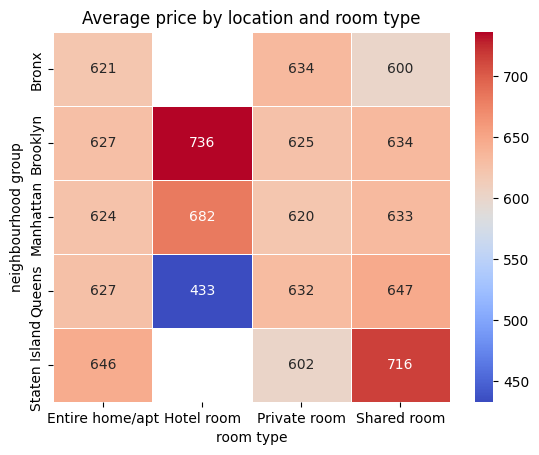

In [146]:
#heatmapa - srednie ceny po lokacji i typie
pivot = df_airbnb.pivot_table(
    values="price",
    index="neighbourhood group",
    columns="room type",
    aggfunc="mean"
)

sns.heatmap(pivot, annot=True, cmap="coolwarm", fmt=".0f", linewidths=0.5)
plt.title("Average price by location and room type")
plt.show()

Analiza średnich cen w podziale na dzielnice oraz typy pokoi pokazuje, że lokalizacja ma istotny wpływ na poziom cen, jednak zależność między typem pokoju a ceną nie jest jednoznaczna.

W większości dzielnic ceny dla „Entire home/apt” oraz „Private room” są bardzo zbliżone, co sugeruje, że rynek nie różnicuje ich znacząco pod względem wartości.

Jednocześnie zauważalna jest nietypowa sytuacja, w której „Shared room” osiąga najwyższe średnie ceny w kilku lokalizacjach (np. Bronx, Queens), co może wynikać z ograniczonej liczby ofert lub obecności wartości odstających.

Najbardziej stabilne i przewidywalne ceny występują w dzielnicach takich jak Manhattan i Brooklyn, gdzie różnice pomiędzy typami pokoi są niewielkie. Z kolei w dzielnicach takich jak Bronx czy Staten Island widoczne są większe wahania, co sugeruje mniej stabilny rynek.

Dla nowych gospodarzy kluczowe znaczenie ma analiza lokalnego rynku, ponieważ to lokalizacja w większym stopniu determinuje poziom cen niż typ oferowanego pokoju. W związku z tym rekomendowane jest dostosowanie ceny do średnich wartości w danej dzielnicy, zamiast opierania strategii wyłącznie na rodzaju nieruchomości.

Czyli:
Lokalizacja ma większy wpływ na cenę niż typ pokoju, a różnice między „Entire home” i „Private room” są często minimalne.

In [147]:
df_airbnb.to_excel("airbnb_cleaned.xlsx", index=False)